# 03 - Economic Optimization Analysis

This notebook analyzes the results of the solar and battery economic optimization.

The goal is to compare different photovoltaic and battery configurations according to:

- Investment cost
- Annual savings
- Payback period
- Grid electricity imports
- Solar surplus
- Self-sufficiency

The main idea is to understand the trade-off between economic profitability and energy independence.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent

GRID_SEARCH_RESULTS_PATH = PROJECT_ROOT / "reports" / "grid_search_results.csv"
BEST_SCENARIOS_PATH = PROJECT_ROOT / "reports" / "best_scenarios.csv"

## Load optimization results

We load the full grid search results and the selected best scenarios.

In [3]:
grid_df = pd.read_csv(GRID_SEARCH_RESULTS_PATH)
best_df = pd.read_csv(BEST_SCENARIOS_PATH)

grid_df.head()

,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,period_cost_eur,annual_cost_eur,period_savings_eur,annual_savings_eur,payback_years,grid_import_kwh,solar_surplus_kwh,potential_surplus_compensation_eur,self_sufficiency
0,0.5,0.0,1250.0,29.196771,355.227386,16.735222,203.611864,6.139131,154.235184,23.575217,1.650265,0.328419
1,0.5,0.5,1500.0,27.368068,332.978164,18.563925,225.861087,6.641250,139.273066,6.950643,0.486545,0.393568
2,0.5,1.0,1750.0,26.603498,323.675887,19.328496,235.163364,7.441635,133.017488,0.000000,0.000000,0.420807
3,0.5,2.0,2250.0,26.603498,323.675887,19.328496,235.163364,9.567817,133.017488,0.000000,0.000000,0.420807
4,0.5,3.0,2750.0,26.603498,323.675887,19.328496,235.163364,11.693998,133.017488,0.000000,0.000000,0.420807


## Grid search overview

Each row represents one solar and battery configuration.

In [4]:
print(f"Number of scenarios: {len(grid_df)}")
print(f"Solar peak power values: {sorted(grid_df['solar_peak_power_kw'].unique())}")
print(f"Battery capacity values: {sorted(grid_df['battery_capacity_kwh'].unique())}")

Number of scenarios: 30
Solar peak power values: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0)]
Battery capacity values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0)]


## Best scenario by payback

The best economic scenario is the one with the minimum payback period.

In [5]:
best_payback = best_df[best_df["criterion"] == "best_payback"].iloc[0]

best_payback

criterion               best_payback
solar_peak_power_kw              1.5
battery_capacity_kwh             0.0
investment_cost_eur           2150.0
annual_savings_eur        428.942264
payback_years                5.01233
self_sufficiency            0.484513
grid_import_kwh            118.38667
solar_surplus_kwh         185.726704
Name: 0, dtype: object

This scenario minimizes the time needed to recover the initial investment through annual savings.

## Best scenario by self-sufficiency

The best energy scenario is the one with the highest self-sufficiency.

In [6]:
best_self_sufficiency = best_df[
    best_df["criterion"] == "best_self_sufficiency"
].iloc[0]

best_self_sufficiency

criterion               best_self_sufficiency
solar_peak_power_kw                       1.5
battery_capacity_kwh                      5.0
investment_cost_eur                    4650.0
annual_savings_eur                 558.839251
payback_years                        8.320819
self_sufficiency                     0.994155
grid_import_kwh                      1.342265
solar_surplus_kwh                   52.628367
Name: 1, dtype: object

This scenario maximizes the percentage of household electricity demand covered by the solar and battery system.

## Economic optimum vs energy optimum

We compare the two selected scenarios.

In [7]:
comparison_columns = [
    "criterion",
    "solar_peak_power_kw",
    "battery_capacity_kwh",
    "investment_cost_eur",
    "annual_savings_eur",
    "payback_years",
    "self_sufficiency",
    "grid_import_kwh",
    "solar_surplus_kwh"
]

best_df[comparison_columns]

,criterion,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,annual_savings_eur,payback_years,self_sufficiency,grid_import_kwh,solar_surplus_kwh
0,best_payback,1.5,0.0,2150.0,428.942264,5.012330,0.484513,118.386670,185.726704
1,best_self_sufficiency,1.5,5.0,4650.0,558.839251,8.320819,0.994155,1.342265,52.628367


## Payback period by solar power and battery capacity

This plot shows how the payback period changes across different solar and battery configurations.

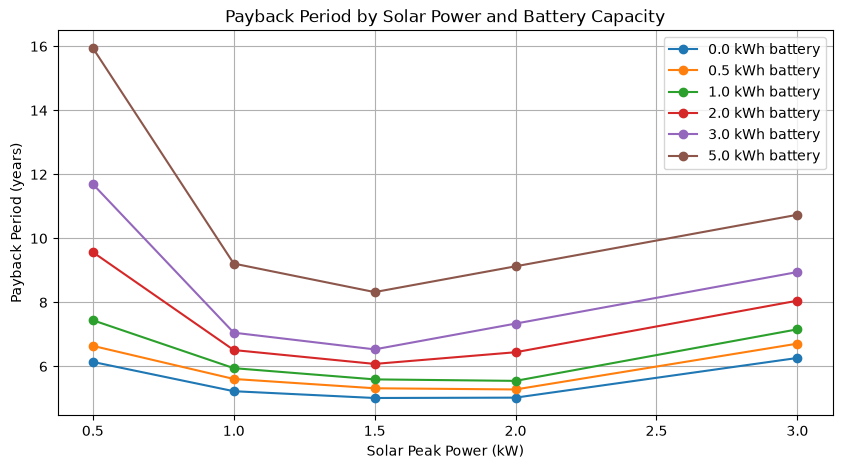

In [8]:
plt.figure(figsize=(10, 5))

for battery_capacity_kwh in sorted(grid_df["battery_capacity_kwh"].unique()):
    battery_df = grid_df[
        grid_df["battery_capacity_kwh"] == battery_capacity_kwh
    ]

    plt.plot(
        battery_df["solar_peak_power_kw"],
        battery_df["payback_years"],
        marker="o",
        label=f"{battery_capacity_kwh} kWh battery"
    )

plt.title("Payback Period by Solar Power and Battery Capacity")
plt.xlabel("Solar Peak Power (kW)")
plt.ylabel("Payback Period (years)")
plt.grid(True)
plt.legend()

plt.show()

## Self-sufficiency by solar power and battery capacity

This plot shows how increasing solar power and battery capacity affects energy independence.

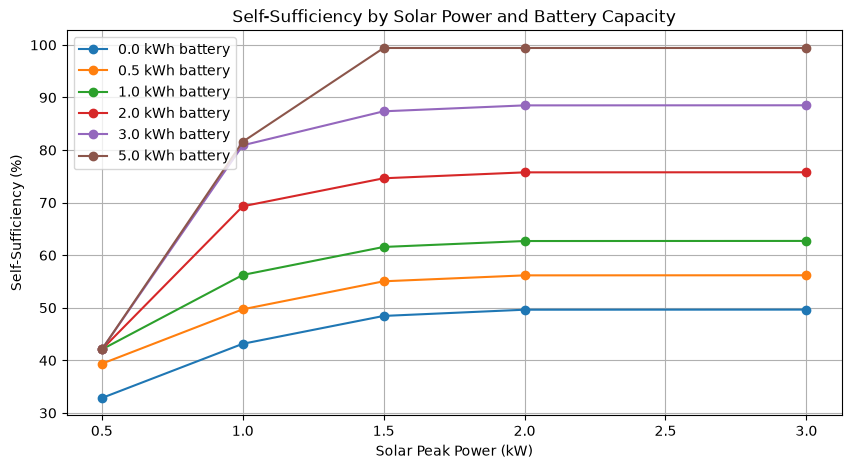

In [9]:
plt.figure(figsize=(10, 5))

for battery_capacity_kwh in sorted(grid_df["battery_capacity_kwh"].unique()):
    battery_df = grid_df[
        grid_df["battery_capacity_kwh"] == battery_capacity_kwh
    ]

    plt.plot(
        battery_df["solar_peak_power_kw"],
        battery_df["self_sufficiency"] * 100,
        marker="o",
        label=f"{battery_capacity_kwh} kWh battery"
    )

plt.title("Self-Sufficiency by Solar Power and Battery Capacity")
plt.xlabel("Solar Peak Power (kW)")
plt.ylabel("Self-Sufficiency (%)")
plt.grid(True)
plt.legend()

plt.show()

## Payback vs self-sufficiency

This scatter plot shows the trade-off between economic profitability and energy independence.

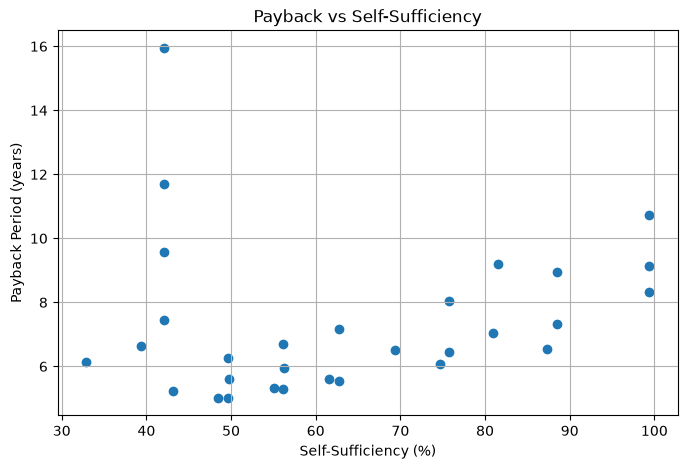

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    grid_df["self_sufficiency"] * 100,
    grid_df["payback_years"]
)

plt.title("Payback vs Self-Sufficiency")
plt.xlabel("Self-Sufficiency (%)")
plt.ylabel("Payback Period (years)")
plt.grid(True)

plt.show()

## Investment cost vs annual savings

Higher investment can increase savings, but it does not always lead to a shorter payback period.

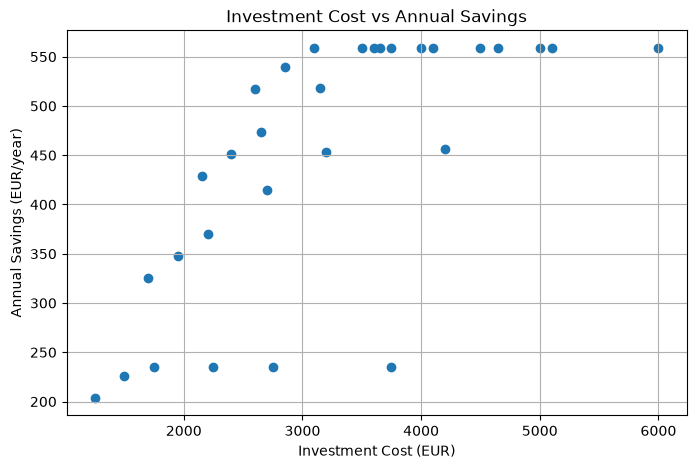

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    grid_df["investment_cost_eur"],
    grid_df["annual_savings_eur"]
)

plt.title("Investment Cost vs Annual Savings")
plt.xlabel("Investment Cost (EUR)")
plt.ylabel("Annual Savings (EUR/year)")
plt.grid(True)

plt.show()

## Top scenarios by payback

The following table shows the configurations with the shortest payback period.

In [12]:
grid_df.sort_values("payback_years").head(10)[
    [
        "solar_peak_power_kw",
        "battery_capacity_kwh",
        "investment_cost_eur",
        "annual_savings_eur",
        "payback_years",
        "self_sufficiency"
    ]
]

,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,annual_savings_eur,payback_years,self_sufficiency
12,1.5,0.0,2150.0,428.942264,5.012330,0.484513
18,2.0,0.0,2600.0,517.561606,5.023557,0.496363
6,1.0,0.0,1700.0,325.381989,5.224628,0.431532
19,2.0,0.5,2850.0,539.867161,5.279076,0.561677
13,1.5,0.5,2400.0,451.445539,5.316256,0.550406
20,2.0,1.0,3100.0,558.839251,5.547212,0.626991
14,1.5,1.0,2650.0,473.751095,5.593655,0.615720
7,1.0,0.5,1950.0,347.784424,5.606922,0.497129
8,1.0,1.0,2200.0,370.089979,5.944500,0.562443
15,1.5,2.0,3150.0,518.362206,6.076832,0.746348


## Top scenarios by self-sufficiency

The following table shows the configurations with the highest self-sufficiency.

In [13]:
grid_df.sort_values("self_sufficiency", ascending=False).head(10)[
    [
        "solar_peak_power_kw",
        "battery_capacity_kwh",
        "investment_cost_eur",
        "annual_savings_eur",
        "payback_years",
        "self_sufficiency"
    ]
]

,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,annual_savings_eur,payback_years,self_sufficiency
23,2.0,5.0,5100.0,558.839251,9.126059,0.994155
17,1.5,5.0,4650.0,558.839251,8.320819,0.994155
29,3.0,5.0,6000.0,558.839251,10.736540,0.994155
28,3.0,3.0,5000.0,558.839251,8.947117,0.885191
22,2.0,3.0,4100.0,558.839251,7.336636,0.885007
16,1.5,3.0,3650.0,558.839251,6.531395,0.873736
11,1.0,5.0,4200.0,455.939321,9.211752,0.815868
10,1.0,3.0,3200.0,453.723241,7.052758,0.809061
27,3.0,2.0,4500.0,558.839251,8.052405,0.757803
21,2.0,2.0,3600.0,558.839251,6.441924,0.757619


## Conclusions

The optimization results show a clear trade-off between economic performance and energy independence.

The best payback scenario minimizes the investment recovery time, but it does not necessarily maximize self-sufficiency.

The best self-sufficiency scenario can greatly reduce grid imports, but it usually requires a larger battery investment, increasing the payback period.

This confirms one of the main insights of the project:

> The economically optimal solar configuration is not always the most energy-independent configuration.